## 🚦 Priorización de Intervenciones por Severidad de Anomalías

Este notebook genera un ranking de severidad de anomalías por pozo y etapa, utilizando los scores de modelos no supervisados.

Nos permite responder:
- ¿Qué etapas presentan más anomalías?
- ¿Dónde se concentran los scores más altos?
- ¿Qué pozos deberían priorizarse para inspección o acciones correctivas?

#### 🎯 Objetivo:

Calcular un score de severidad o “prioridad de intervención” por etapa.

Analizar:

- Cuántas anomalías hay por etapa.
- Qué tan severas son (según score máximo, media, etc.).
- Identificar las etapas más críticas.
- Visualizar todo con tablas y gráficos comparativos.


### 📂 Celda 2 – Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset con anomalías
df = pd.read_csv(r"C:\Developer\fundamentos\data\ccl_anomaly_scores.csv")

# Seleccionamos score principal para el ranking
SCORE_COL = "score_iso"


### 🧮 Celda 3 – Cálculo del score de severidad por etapa

In [2]:
# Agrupar por pozo, etapa, sentido (si es relevante)
grupo = df.groupby(["pozo", "etapa"])

# Crear tabla resumen
ranking = grupo.agg(
    n_puntos=("DEPT", "count"),
    score_max=(SCORE_COL, "max"),
    score_mean=(SCORE_COL, "mean"),
    score_std=(SCORE_COL, "std"),
    n_anomalias=(SCORE_COL, lambda x: (x > x.quantile(0.85)).sum())
).reset_index()

# Crear un score combinado (puede ajustarse)
ranking["severity_score"] = (
    ranking["score_mean"] * 0.5 +
    ranking["score_max"] * 0.3 +
    ranking["n_anomalias"] / ranking["n_puntos"] * 0.2
)


### 📊 Celda 4 – Visualización del ranking

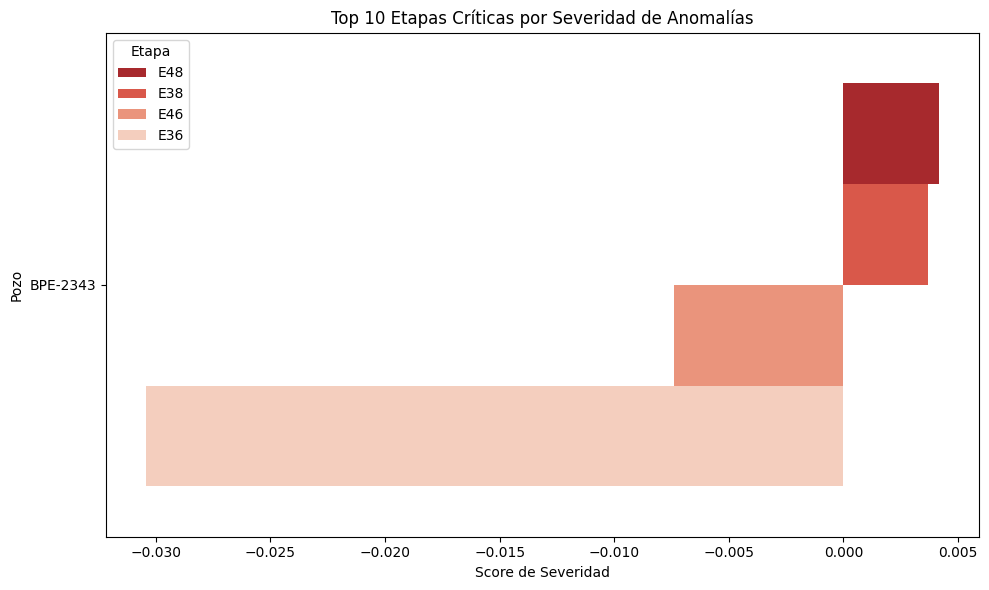

In [4]:
# Mostrar top 10 etapas críticas
top_n = 10
ranking_top = ranking.sort_values("severity_score", ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(data=ranking_top, x="severity_score", y="pozo", hue="etapa", palette="Reds_r")
plt.title(f"Top {top_n} Etapas Críticas por Severidad de Anomalías")
plt.xlabel("Score de Severidad")
plt.ylabel("Pozo")
plt.legend(title="Etapa")
plt.tight_layout()
plt.show()


### 📋 Celda 5 – Tabla completa ordenada

In [5]:
# Tabla ordenada completa
ranking.sort_values("severity_score", ascending=False).head(20)


,pozo,etapa,n_puntos,score_max,score_mean,score_std,n_anomalias,severity_score
3,BPE-2343,E48,17892,0.090163,-0.105711,0.031016,2684,0.004196
1,BPE-2343,E38,28617,0.080880,-0.101182,0.037863,4293,0.003676
2,BPE-2343,E46,19729,0.056548,-0.108708,0.031627,2960,-0.007383
0,BPE-2343,E36,30538,0.018480,-0.131991,0.029817,4581,-0.030450


### 💾 Celda 6 – Exportación para operaciones

In [6]:
ranking.to_csv(r"C:\Developer\fundamentos\data\etapas_priorizadas.csv", index=False)
print("✅ Exportado como etapas_priorizadas.csv")


✅ Exportado como etapas_priorizadas.csv
